In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn
from pyro.infer import Predictive

###PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

###Forward and Backward Selection
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import statsmodels.api as sm

# HMC
from pyro.infer import MCMC, NUTS

# variational inference
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from tqdm.auto import trange

import matplotlib as mpl
import os
import sys
import math

In [2]:
sys.path.append(
    r"C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior"
)

In [3]:
from optbnn.gp.models.gpr import GPR
from optbnn.gp import kernels, mean_functions, priors
from optbnn.bnn.reparam_nets import GaussianMLPReparameterization
from optbnn.bnn.nets.mlp import MLP
from optbnn.bnn.likelihoods import LikGaussian
from optbnn.bnn.priors import FixedGaussianPrior, OptimGaussianPrior
from optbnn.prior_mappers.wasserstein_mapper import MapperWasserstein, WassersteinDistance
from optbnn.utils.rand_generators import MeasureSetGenerator, GridGenerator
from optbnn.utils.normalization import normalize_data
from optbnn.utils.exp_utils import get_input_range
from optbnn.metrics.sampling import compute_rhat_regression
from optbnn.metrics import uncertainty as uncertainty_metrics
from optbnn.sgmcmc_bayes_net.regression_net import RegressionNet
from optbnn.utils import util

### 1. concatenated records

#### 1.1 records before GDPR

In [4]:
df_pre = pd.read_csv("pregdprApril2016_Infineon.csv")
df_pre = df_pre.dropna()
df_pre.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,1.128878e+09,11.125,10.0,1.0,1.099981,1.128878e+09,11.295,10.0,1.0,1.099981,...,11.310,10.0,1.0,1.099981,1.128878e+09,11.585,10.0,1.0,1.099981,11.443525
1,1.128878e+09,11.295,10.0,1.0,1.099981,1.128878e+09,11.300,10.0,1.0,1.099981,...,11.585,10.0,1.0,1.099981,1.128878e+09,11.775,10.0,1.0,1.099981,11.492236
2,1.128878e+09,11.300,10.0,1.0,1.099981,1.128878e+09,11.310,10.0,1.0,1.099981,...,11.775,10.0,1.0,1.099981,1.128878e+09,11.835,10.0,1.0,1.099981,11.223600
3,1.128878e+09,11.310,10.0,1.0,1.099981,1.128878e+09,11.585,10.0,1.0,1.099981,...,11.835,10.0,1.0,1.099981,1.128878e+09,11.715,10.0,1.0,1.099981,11.153491
4,1.128878e+09,11.585,10.0,1.0,1.099981,1.128878e+09,11.775,10.0,1.0,1.099981,...,11.715,10.0,1.0,1.099981,1.128878e+09,11.540,10.0,1.0,1.099981,11.040598


In [5]:
X_pre = df_pre.iloc[:, : -1].values
X_pre, X_pre.shape, type(X_pre)

(array([[1.12887816e+09, 1.11250000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.09998087e+00],
        [1.12887816e+09, 1.12950000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.09998087e+00],
        [1.12887816e+09, 1.13000000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.09998087e+00],
        ...,
        [1.13134987e+09, 1.24450000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.11952740e+00],
        [1.13134987e+09, 1.23850000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.11952740e+00],
        [1.13134987e+09, 1.25700000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.11952740e+00]]),
 (266, 25),
 numpy.ndarray)

In [6]:
y_pre = df_pre["target"].values
y_pre, y_pre.shape, type(y_pre)

(array([11.44352502, 11.4922365 , 11.22359974, 11.15349149, 11.04059798,
        11.18251236, 11.32496504, 11.31764717, 11.07462343, 11.05354403,
        11.20534498, 11.03489352, 10.79466901, 10.59649096, 11.00674944,
        10.89673307, 11.18719478, 11.53074089, 11.27257885, 11.27144657,
        11.38556089, 11.27581629, 11.32137574, 11.44955844, 11.55147418,
        11.51647984, 11.52146218, 11.45560632, 11.28928394, 11.36051696,
        11.3594827 , 11.78862238, 11.74224603, 11.84518421, 11.87725301,
        11.95350099, 11.98753049, 11.96592096, 11.92008901, 11.70835292,
        11.47165135, 11.433611  , 11.72745668, 11.78777873, 11.82811791,
        11.86276427, 11.72382344, 11.75627195, 11.80854113, 11.67604344,
        11.63043946, 11.72164514, 11.67433403, 11.58214585, 11.52025676,
        11.59478612, 11.42727995, 11.46147668, 11.52942315, 11.31521607,
        11.25326374, 11.17271181, 11.22467361, 10.97981597, 10.8248963 ,
        10.79425731, 10.75904374, 10.7884494 , 10.6

#### 1.2 records after GDPR

In [7]:
df_post = pd.read_csv("postgdprMay2018_Infineon.csv")
df_post = df_post.dropna()
df_post.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,1.136451e+09,23.46,10.0,1.0,1.146751,1.136451e+09,23.79,10.0,1.0,1.146751,...,24.41,10.0,1.0,1.146751,1.136451e+09,23.85,10.0,1.0,1.146751,19.094758
1,1.136451e+09,23.79,10.0,1.0,1.146751,1.136451e+09,24.42,10.0,1.0,1.146751,...,23.85,10.0,1.0,1.146751,1.136451e+09,24.85,10.0,1.0,1.146751,18.751720
2,1.136451e+09,24.42,10.0,1.0,1.146751,1.136451e+09,24.41,10.0,1.0,1.146751,...,24.85,10.0,1.0,1.146751,1.136451e+09,24.44,10.0,1.0,1.146751,18.980356
3,1.136451e+09,24.41,10.0,1.0,1.146751,1.136451e+09,23.85,10.0,1.0,1.146751,...,24.44,10.0,1.0,1.146751,1.136451e+09,24.71,10.0,1.0,1.146751,19.056626
4,1.136451e+09,23.85,10.0,1.0,1.146751,1.136451e+09,24.85,10.0,1.0,1.146751,...,24.71,10.0,1.0,1.146751,1.136451e+09,24.79,10.0,1.0,1.146751,18.993672


In [8]:
X_post = df_post.iloc[:, : -1].values
X_post, X_post.shape, type(X_post)

(array([[1.13645068e+09, 2.34600000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.14675142e+00],
        [1.13645068e+09, 2.37900000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.14675142e+00],
        [1.13645068e+09, 2.44200000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.14675142e+00],
        ...,
        [1.25068407e+09, 2.08750000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.16250030e+00],
        [1.25068407e+09, 2.07750000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.16250030e+00],
        [1.25068407e+09, 2.06750000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.16250030e+00]]),
 (391, 25),
 numpy.ndarray)

In [9]:
y_post = df_post["target"].values
y_post, y_post.shape, type(y_post)

(array([19.0947582 , 18.75172023, 18.98035571, 19.0566265 , 18.99367201,
        18.9649805 , 18.65611801, 18.57370873, 18.26004388, 17.48885524,
        17.02865976, 17.12815528, 17.08074469, 16.45093426, 16.7250298 ,
        16.45533186, 16.28416148, 15.92688801, 16.25331721, 16.25050737,
        16.37446186, 16.47657781, 16.38998261, 16.33272518, 16.41192469,
        16.67679604, 16.80352017, 17.15581748, 17.20947284, 17.02635651,
        16.93577136, 16.97112633, 16.4211094 , 16.52006707, 16.58285645,
        16.49853644, 16.38476562, 15.96543363, 16.32603596, 16.2048406 ,
        16.27491254, 16.17618731, 16.41389487, 16.41905081, 16.18143163,
        16.30660921, 16.20914372, 15.88317042, 16.06028618, 15.86751428,
        15.81804087, 16.02798524, 15.79247341, 15.98772341, 16.08626979,
        16.37858047, 16.38281463, 16.34773769, 16.39423936, 16.42389516,
        16.3672828 , 16.16892586, 15.92338509, 15.76350816, 15.44437769,
        15.42096768, 15.13656595, 14.18928494, 14.6

### 2. BNN and plot functions

In [10]:
class BNN(PyroModule):
    def __init__(self, weight_prior, bias_prior, in_dim=1, out_dim=1, hid_dim=10, n_hid_layers=5):
        '''
        functional model (network architecture):
            a fully connected neural network.

        stochastic model:
            Gaussian prior on weight and bias: p(theta) ~ dist.Normal(0., weight_prior or bias_prior), where weight_prior and bias_prior are learned;
            Gaussian likelihood function: p(y | x, theta) ~ dist.Normal(functional model(x), sigma^2), where sigma ~ dist.Gamma(.5, 1).
        '''
        super().__init__()

        # make sure the dimensions are valid
        assert in_dim > 0 and out_dim > 0 and hid_dim > 0 and n_hid_layers > 0

        # activation function for the whole network, can also be ReLU or LeakyReLU
        self.activation = nn.Tanh()

        # define the layer sizes and the PyroModule layer list
        self.layer_sizes = [in_dim] + n_hid_layers * [hid_dim] + [out_dim]
        layer_list = [PyroModule[nn.Linear](self.layer_sizes[idx - 1], self.layer_sizes[idx]) for idx in
                      range(1, len(self.layer_sizes))]
        self.layers = PyroModule[torch.nn.ModuleList](layer_list)

        # set the probability distribution for each layer's weight and bias
        for layer_idx, layer in enumerate(self.layers):
            layer.weight = PyroSample(dist.Normal(0., weight_prior[layer_idx]).expand([self.layer_sizes[layer_idx + 1], self.layer_sizes[layer_idx]]).to_event(2))
            layer.bias = PyroSample(dist.Normal(0., bias_prior[layer_idx]).expand([self.layer_sizes[layer_idx + 1]]).to_event(1))

    def forward(self, x, y=None):
        # functional model(x)
        # input --> hidden
        x = self.activation(self.layers[0](x))
        # hidden --> hidden
        for layer in self.layers[1:-1]:
            x = self.activation(layer(x))
        # hidden --> output
        mu = self.layers[-1](x).squeeze()

        # sample from P(y | x, \theta)
        sigma = pyro.sample("sigma", dist.Gamma(.5, 1))
        with pyro.plate("data", x.shape[0]):
            # obs is used when quantifying and visualizing the uncertainty of predictions
            obs = pyro.sample("obs", dist.Normal(mu, sigma * sigma), obs=y)
        
        return mu

In [11]:
def plot_predictions(preds, y):
    '''
    Function to visualize the predictions and the uncertainty of predictions.
    '''
    y_pred = preds['obs'].T.detach().numpy().mean(axis=1)
    y_std = preds['obs'].T.detach().numpy().std(axis=1)

    fig, ax = plt.subplots(figsize=(10, 5))

    # decide the range of the y axis based on the number of the labels
    time_idx = np.array(range(len(y)))
    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    # decide the range of the y axis based on the range of the labels
    ylims = [min(y.min(), y_pred.min()) - 20,
             max(y.max(), y_pred.max()) + 20]
    
    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("time", fontsize=20)
    plt.ylabel("closing price", fontsize=20)

    ax.plot(time_idx, y, 'ko', markersize=1, label="observations")
    ax.plot(time_idx, y_pred, '-', linewidth=0.5, color="#408765", label="predictive mean")
    ax.fill_between(time_idx, y_pred - 2 * y_std, y_pred + 2 * y_std, alpha=0.6, color='#86cfac', zorder=0)

    plt.legend(loc=4, fontsize=15, frameon=False)

In [12]:
def plot_uncertainty(preds, y):
    '''
    Function to visualize only the uncertainty.
    '''
    fig, ax = plt.subplots(figsize=(10, 5))

    time_idx = np.array(range(len(y)))
    y_std = preds['obs'].T.detach().numpy().std(axis=1)

    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    ylims = [y_std.min() - 0.5, y_std.max() + 0.5]

    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("time", fontsize=20)
    plt.ylabel("std of closing price", fontsize=20)

    ax.plot(time_idx, y_std, 'ko', markersize=1, label="std of predictions")
    ax.plot(time_idx, y_std, '-', linewidth=0.5, color="#408765")

    plt.legend(loc=4, fontsize=15, frameon=False)

### 3. uncertainty quantification of data pre GDPR

#### 3.1 Train the prior of BNN.

In [13]:
###IGNORE THIS IF YOU DON'T HAVE CUDA
import torch

print("CUDA Available:", torch.cuda.is_available())
print("CUDA Device Count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("CUDA Device Name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")
print(torch.version.cuda)
print(torch.cuda.device_count())

CUDA Available: True
CUDA Device Count: 1
CUDA Device Name: NVIDIA GeForce RTX 4070
Training on device: cuda
11.8
1


In [14]:
%time 
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 250  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_pre_n, y_pre_n, y_mean, y_std = normalize_data(X_pre, y_pre)
x_min, x_max = get_input_range(X_pre_n, X_pre_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_pre.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_pre_n, x_min, x_max, 0.7)

# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_pre_n), Y=torch.from_numpy(y_pre_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 250), ###more than 200
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=1, gpu_gp=True) ##Change GPU if you don't have CUDA; same thing for the post training
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

CPU times: total: 0 ns
Wall time: 0 ns


C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Resize.cpp:37.)
  return torch.log(torch.exp(t) - 1, out=out)
C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\models\model.py:136: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch

>>> Iteration #   1: Wasserstein Dist 9.0197
>>> Iteration #  10: Wasserstein Dist 2.7869
>>> Iteration #  20: Wasserstein Dist 1.0835
>>> Iteration #  30: Wasserstein Dist 0.2555
>>> Iteration #  40: Wasserstein Dist 2.2926
>>> Iteration #  50: Wasserstein Dist 2.0028
>>> Iteration #  60: Wasserstein Dist -0.1474
>>> Iteration #  70: Wasserstein Dist 1.3185
>>> Iteration #  80: Wasserstein Dist 0.2250
>>> Iteration #  90: Wasserstein Dist 0.7931
>>> Iteration # 100: Wasserstein Dist 1.6706
>>> Iteration # 110: Wasserstein Dist 1.0907
>>> Iteration # 120: Wasserstein Dist 0.9373
>>> Iteration # 130: Wasserstein Dist 0.8379
>>> Iteration # 140: Wasserstein Dist 0.3087
>>> Iteration # 150: Wasserstein Dist 0.5490
>>> Iteration # 160: Wasserstein Dist -0.2786
>>> Iteration # 170: Wasserstein Dist 1.6980
>>> Iteration # 180: Wasserstein Dist 0.8241
>>> Iteration # 190: Wasserstein Dist 0.3920
>>> Iteration # 200: Wasserstein Dist -0.0743
>>> Iteration # 210: Wasserstein Dist -1.3221
>>> It

In [15]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([3.3984], device='cuda:0', requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([2.6759], device='cuda:0', requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.2921], device='cuda:0', requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-1.4769], device='cuda:0', requires_grad=True)


In [16]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

pre_weight_prior = [maintain_positivity(3.6905), maintain_positivity(1.3724)]
pre_bias_prior = [maintain_positivity(2.9497), maintain_positivity(-0.8432)]

#### 3.2 train the BNN

In [17]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(pre_weight_prior, pre_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [18]:
###Better Rendering
from tqdm.notebook import trange
# or use tqdm.auto to auto-detect
from tqdm.auto import trange

In [19]:
%time
num_epochs = 12000 # number of training epoches, 10000 now for quick test: 25000
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_pre_n_tensor = torch.tensor(X_pre_n, dtype=torch.float)
y_pre_n_tensor = torch.tensor(y_pre_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_pre_n_tensor, y_pre_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_pre_n.shape[0]:.3f}")
    if epoch % 100 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_pre_n.shape[0])) #43.750

CPU times: total: 0 ns
Wall time: 0 ns


  0%|          | 0/12000 [00:00<?, ?it/s]

[iteration 0001] loss: 529.115
[iteration 0101] loss: 2026.332
[iteration 0201] loss: 750.603
[iteration 0301] loss: 445.158
[iteration 0401] loss: 998.980
[iteration 0501] loss: 7931.829
[iteration 0601] loss: 1200.769
[iteration 0701] loss: 1708.150
[iteration 0801] loss: 1336.926
[iteration 0901] loss: 6109.119
[iteration 1001] loss: 2335.294
[iteration 1101] loss: 607.369
[iteration 1201] loss: 401.004
[iteration 1301] loss: 1996.723
[iteration 1401] loss: 71.987
[iteration 1501] loss: 715.481
[iteration 1601] loss: 754.512
[iteration 1701] loss: 56.847
[iteration 1801] loss: 223.623
[iteration 1901] loss: 105.430
[iteration 2001] loss: 45.962
[iteration 2101] loss: 46.371
[iteration 2201] loss: 74.278
[iteration 2301] loss: 80.816
[iteration 2401] loss: 113.947
[iteration 2501] loss: 236.415
[iteration 2601] loss: 45.787
[iteration 2701] loss: 43.176
[iteration 2801] loss: 95.049
[iteration 2901] loss: 99.703
[iteration 3001] loss: 43.706
[iteration 3101] loss: 61.099
[iteration 3

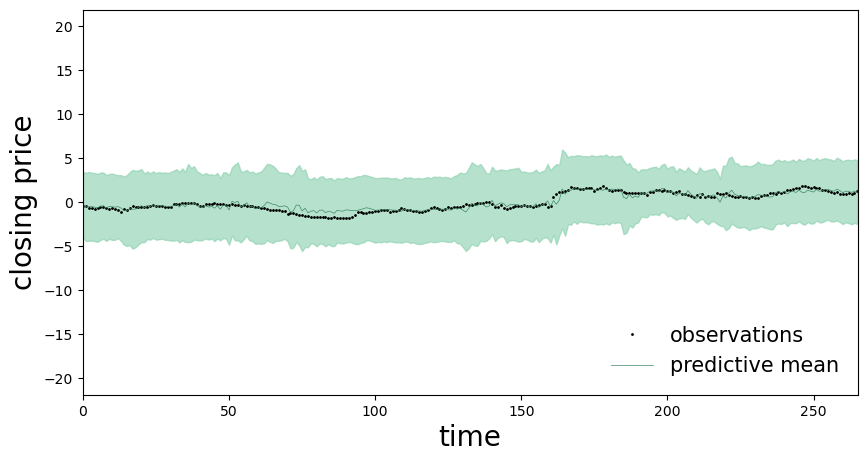

In [20]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)

preds = predictive(X_pre_n_tensor)

plot_predictions(preds, y_pre_n_tensor)

In [21]:
pred_samples = preds["obs"]
pred_mean = pred_samples.mean(dim=0) 
# Calculate RMSE
y_true = y_pre_n_tensor
rmse = torch.sqrt(torch.mean((pred_mean - y_true) ** 2))
print(rmse)

tensor(0.3652)


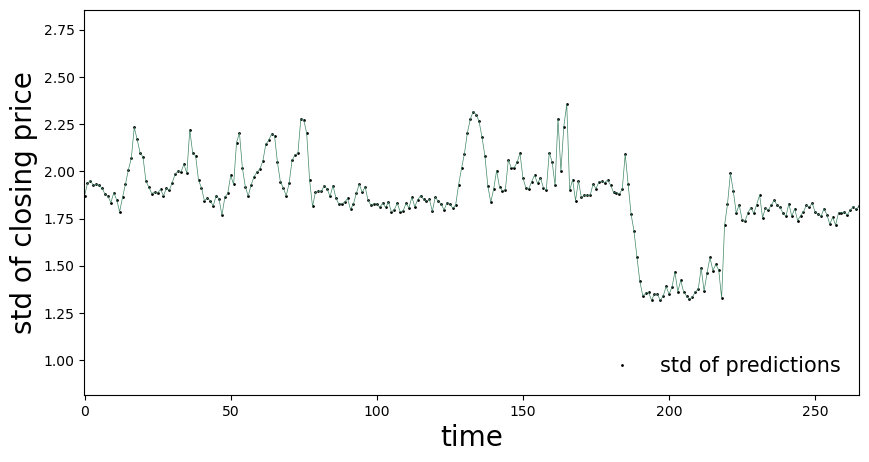

In [22]:
plot_uncertainty(preds, y_pre_n)

### 4. uncertainty quantification of data post GDPR

#### 4.1 Train the prior of BNN.

In [23]:
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 300  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_post_n, y_post_n, y_mean, y_std = normalize_data(X_post, y_post)
x_min, x_max = get_input_range(X_post_n, X_post_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_post.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_post_n, x_min, x_max, 0.7)
    
# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_post_n), Y=torch.from_numpy(y_post_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 300), ##Should be more than 200
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.02,
                               n_gpu=1, gpu_gp=True) ##Change GPU if you don't have CUDA; same thing for the PRE training
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Resize.cpp:37.)
  return torch.log(torch.exp(t) - 1, out=out)


>>> Iteration #   1: Wasserstein Dist 8.7086
>>> Iteration #  10: Wasserstein Dist 1.4574
>>> Iteration #  20: Wasserstein Dist -0.0638
>>> Iteration #  30: Wasserstein Dist 1.9355
>>> Iteration #  40: Wasserstein Dist 1.6290
>>> Iteration #  50: Wasserstein Dist 2.7634
>>> Iteration #  60: Wasserstein Dist -0.0345
>>> Iteration #  70: Wasserstein Dist 1.2501
>>> Iteration #  80: Wasserstein Dist -1.1310
>>> Iteration #  90: Wasserstein Dist 1.3127
>>> Iteration # 100: Wasserstein Dist 1.2513
>>> Iteration # 110: Wasserstein Dist 0.6766
>>> Iteration # 120: Wasserstein Dist 2.3583
>>> Iteration # 130: Wasserstein Dist 2.4729
>>> Iteration # 140: Wasserstein Dist 1.7209
>>> Iteration # 150: Wasserstein Dist 2.4691
>>> Iteration # 160: Wasserstein Dist -0.3037
>>> Iteration # 170: Wasserstein Dist 0.3030
>>> Iteration # 180: Wasserstein Dist 1.3914
>>> Iteration # 190: Wasserstein Dist 1.0362
>>> Iteration # 200: Wasserstein Dist 1.6039
>>> Iteration # 210: Wasserstein Dist 0.3266
>>> It

In [24]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([3.4119], device='cuda:0', requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([2.4374], device='cuda:0', requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.1183], device='cuda:0', requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-0.5074], device='cuda:0', requires_grad=True)


In [25]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

post_weight_prior = [maintain_positivity(3.1053), maintain_positivity(1.1434)]
post_bias_prior = [maintain_positivity(2.0997), maintain_positivity(-0.6430)]

#### 4.2 train the BNN

In [26]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(post_weight_prior, post_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [27]:
num_epochs = 12001 # number of training epoches, 10000 now for quick test
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_post_n_tensor = torch.tensor(X_post_n, dtype=torch.float)
y_post_n_tensor = torch.tensor(y_post_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_post_n_tensor, y_post_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_post_n.shape[0]:.3f}")
    if epoch % 500 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_post_n.shape[0]))

  0%|          | 0/12001 [00:00<?, ?it/s]

[iteration 0001] loss: 286.572
[iteration 0501] loss: 292.832
[iteration 1001] loss: 35.850
[iteration 1501] loss: 29.041
[iteration 2001] loss: 52.350
[iteration 2501] loss: 21.951
[iteration 3001] loss: 32.564
[iteration 3501] loss: 20.996
[iteration 4001] loss: 20.194
[iteration 4501] loss: 20.017
[iteration 5001] loss: 19.860
[iteration 5501] loss: 19.401
[iteration 6001] loss: 18.522
[iteration 6501] loss: 18.192
[iteration 7001] loss: 18.091
[iteration 7501] loss: 17.504
[iteration 8001] loss: 16.568
[iteration 8501] loss: 16.954
[iteration 9001] loss: 16.061
[iteration 9501] loss: 16.970
[iteration 10001] loss: 14.599
[iteration 10501] loss: 14.560
[iteration 11001] loss: 13.096
[iteration 11501] loss: 12.812
[iteration 12001] loss: 12.447


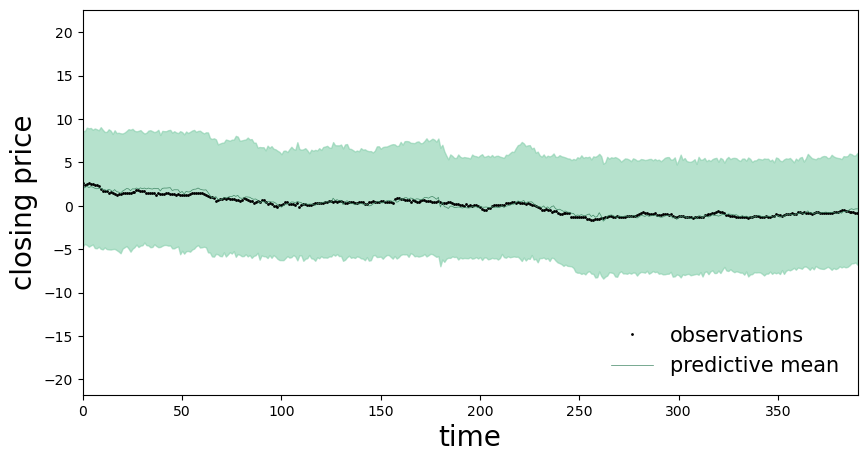

In [28]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)

preds = predictive(X_post_n_tensor)

plot_predictions(preds, y_post_n_tensor)

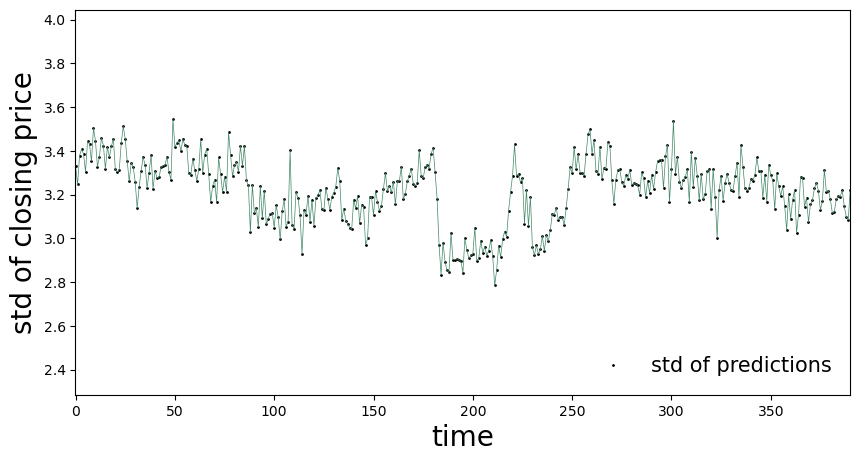

In [29]:
plot_uncertainty(preds, y_post_n)

In [30]:
##RMSE
pred_samples = preds["obs"]
pred_mean = pred_samples.mean(dim=0) 
# Calculate RMSE
y_true = y_post_n_tensor
rmse = torch.sqrt(torch.mean((pred_mean - y_true) ** 2))
print(rmse)

tensor(0.2889)
